# Notebook: Descriptive Statistics & Distributions

---

### Why this matters
Before training any ML model, you need to understand your data. Descriptive statistics and distributions are how you do that. They also tell you:
- Which ML algorithms are safe to use
- What preprocessing is needed (scaling, log transform)
- Where your outliers are
- Whether your features are informative

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(0)
sns.set_theme(style='whitegrid')

```
NumPy -> Raw math — arrays, mean, std, percentiles
Pandas -> Data wrangling — DataFrames, groupby, missing values
Matplotlib/Seaborn -> Visualization
SciPy -> Statistical tests — hypothesis testing, distributions, QQ plot
```

Data wrangling = cleaning and reshaping raw data into a usable format.

Raw data is almost never ready to use directly. It has missing values, wrong data types, duplicates, inconsistent formatting, data spread across multiple tables etc. Wrangling is the process of fixing all that.


## 1. Descriptive Statistics

| Statistic | What it tells you | notes |
|-----------|------------------|---------------|
| **Mean** | Average — pulled by outliers | Not reliable if data is skewed |
| **Median** | Middle value — robust to outliers | Better than mean for skewed data |
| **Std Dev** | Average spread from the mean | Same units as data |
| **Variance** | Std dev squared | Hard to interpret directly — use std dev |
| **Skewness** | Tail direction: + right, - left | > abs(1) means significantly skewed|

> **Key insight:** If mean ≠ median, your data is skewed. Big difference = big skew.

| **Skewness** | Tail direction: + right, - left | \|skewness\| > 1 means significantly skewed |
| --- | --- | --- |
| Positive (+) | Tail stretches to the **right** | More high-value outliers |
| Negative (−) | Tail stretches to the **left** | More low-value outliers |
| ≈ 0 | Symmetric | Normal/no skew |
| \|s\| < 0.5 | Mild skew | Usually acceptable |
| 0.5 < \|s\| < 1 | Moderate skew | Discipline-dependent |
| \|s\| > 1 | **Significant skew** | Transformation may be needed |

=== Salary Data ===
Mean:     $    42,794   ← pulled up by high earners
Median:   $    35,281   ← more representative
Std Dev:  $    27,558
Skewness:      1.688   ← positive = right tail


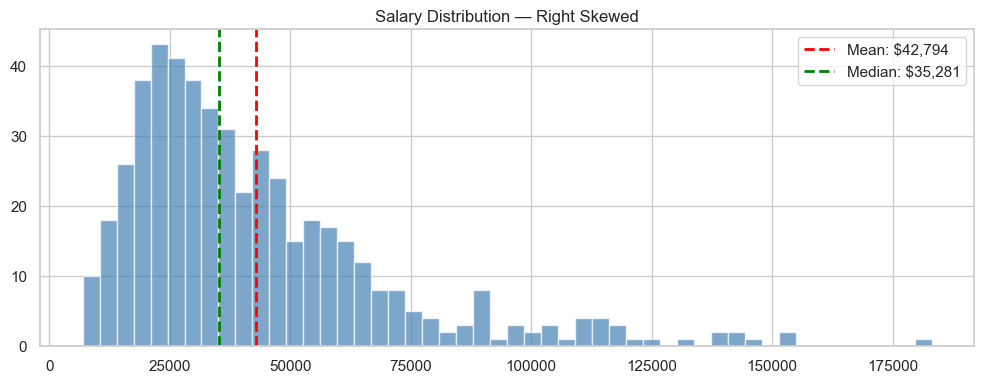

In [9]:
# Simulate salary data — right-skewed (a few high earners pull the mean up)
salaries = np.random.lognormal(mean=10.5, sigma=0.6, size=500)

print("=== Salary Data ===")
print(f"Mean:     ${np.mean(salaries):>10,.0f}   ← pulled up by high earners")
print(f"Median:   ${np.median(salaries):>10,.0f}   ← more representative")
print(f"Std Dev:  ${np.std(salaries):>10,.0f}")
print(f"Skewness: {stats.skew(salaries):>10.3f}   ← positive = right tail")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(salaries, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(np.mean(salaries), color='red', linestyle='--', linewidth=2, label=f'Mean: ${np.mean(salaries):,.0f}')
ax.axvline(np.median(salaries), color='green', linestyle='--', linewidth=2, label=f'Median: ${np.median(salaries):,.0f}')
ax.set_title('Salary Distribution — Right Skewed')
ax.legend()
plt.tight_layout()
plt.show()

## 2. IQR & Outlier Detection

The **Interquartile Range (IQR)** is the distance between Q1 and Q3 — the middle 50% of your data. It's the standard way to define what counts as an outlier.

**IQR fence rule:**
- Lower fence: `Q1 - 1.5 * IQR`
- Upper fence: `Q3 + 1.5 * IQR`

> **Used in:** EDA, preprocessing, anomaly detection, feature engineering. Outliers can destroy linear models.

Q1: $24,002 | Q3: $54,215 | IQR: $30,213
Upper fence: $99,535
Outliers: 28 values (5.6% of data)


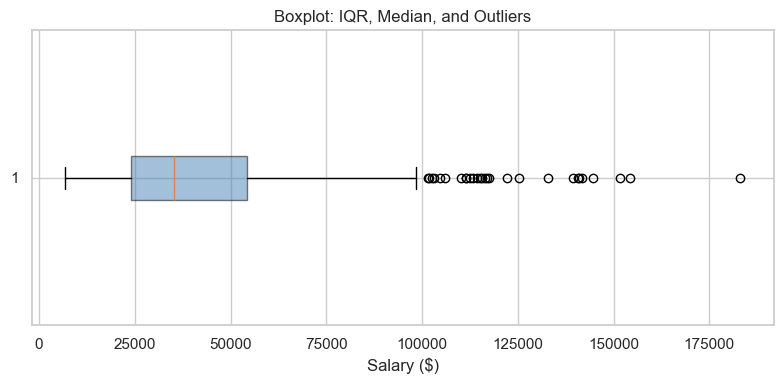

In [10]:
q1, q3 = np.percentile(salaries, [25, 75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outliers = salaries[salaries > upper_fence]

print(f"Q1: ${q1:,.0f} | Q3: ${q3:,.0f} | IQR: ${iqr:,.0f}")
print(f"Upper fence: ${upper_fence:,.0f}")
print(f"Outliers: {len(outliers)} values ({len(outliers)/len(salaries)*100:.1f}% of data)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(salaries, vert=False, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.5))
ax.set_title('Boxplot: IQR, Median, and Outliers')
ax.set_xlabel('Salary ($)')
plt.tight_layout()
plt.show()

## 3. Distribution Types

Knowing your distribution shape determines:
- **Which tests you can run** (many require normality)
- **Which preprocessing to apply** (log transform, power transform)
- **What your data is telling you** (two peaks = two populations)

| Distribution | Common in | Shape |
|-------------|-----------|-------|
| Normal | Heights, test scores, measurement errors | Symmetric bell |
| Right-skewed | Salaries, prices, house values | Long right tail |
| Uniform | Random sampling, dice rolls | Flat |
| Bimodal | Two distinct groups mixed together | Two peaks |

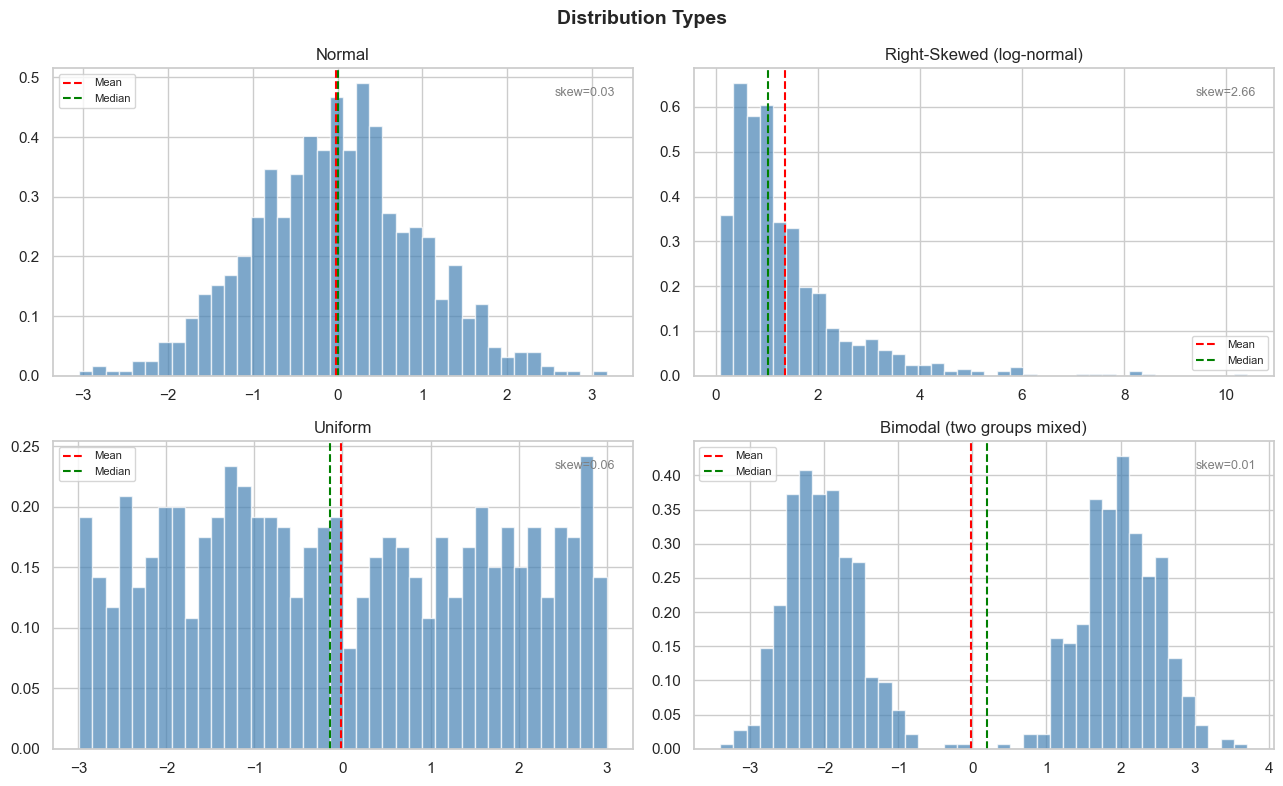

In [11]:
n = 800
dists = {
    'Normal': np.random.normal(0, 1, n),
    'Right-Skewed (log-normal)': np.random.lognormal(0, 0.8, n),
    'Uniform': np.random.uniform(-3, 3, n),
    'Bimodal (two groups mixed)': np.concatenate([
        np.random.normal(-2, 0.5, n // 2),
        np.random.normal(2, 0.5, n // 2)
    ]),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (name, data) in zip(axes.flatten(), dists.items()):
    ax.hist(data, bins=40, color='steelblue', alpha=0.7, edgecolor='white', density=True)
    ax.axvline(np.mean(data), color='red', linestyle='--', linewidth=1.5, label='Mean')
    ax.axvline(np.median(data), color='green', linestyle='--', linewidth=1.5, label='Median')
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.text(0.97, 0.94, f'skew={stats.skew(data):.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')

plt.suptitle('Distribution Types', fontsize=14, fontweight='bold')
plt.tight_layout() 
plt.show()

## 4. QQ Plot — Visual Normality Check

A QQ (quantile-quantile) plot compares your data against a perfect normal distribution.
- **Points on the line** → your data is normal
- **Curved / S-shape** → skewed

> **Used before:** t-tests, ANOVA, linear regression — all assume normality. QQ plot tells you if that assumption holds.

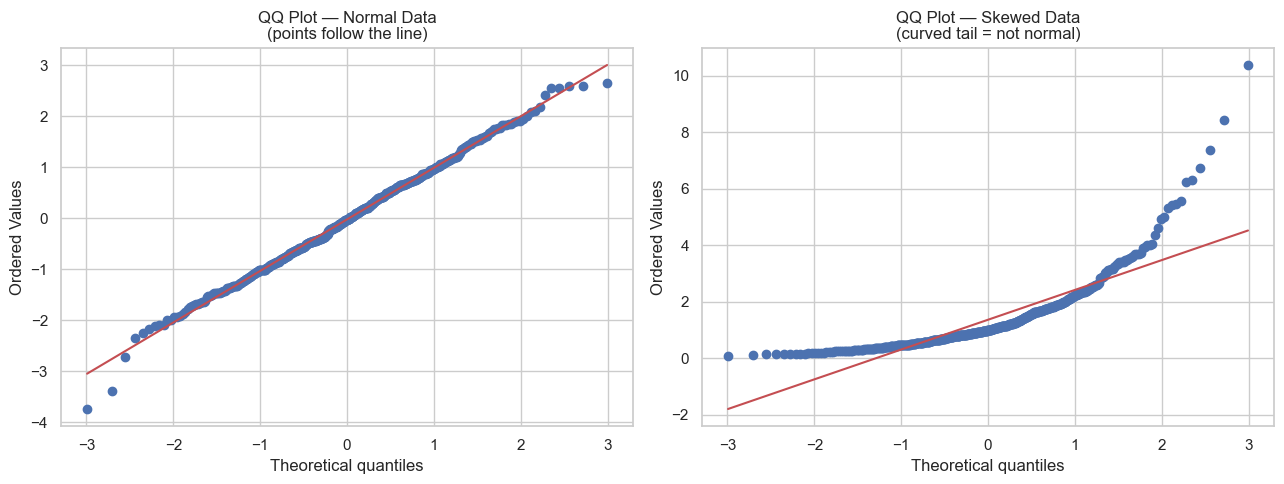

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stats.probplot(np.random.normal(0, 1, 500), dist='norm', plot=axes[0])
axes[0].set_title('QQ Plot — Normal Data\n(points follow the line)')

stats.probplot(np.random.lognormal(0, 0.8, 500), dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot — Skewed Data\n(curved tail = not normal)')

plt.tight_layout()
plt.show()

## Shapiro-Wilk Test

It answers one question: is my data normally distributed?
That's it. It gives you a p-value and you check:

* p > 0.05 → data is likely normal
* p < 0.05 → data is NOT normal

**Why do you need it?**
Before running tests like t-test or linear regression, those methods assume your data is normal. If it's not, the results can be wrong. So Shapiro-Wilk is a safety check you run first.

**Workflow:**

```
Got new data
     ↓
Run Shapiro-Wilk
     ↓
p > 0.05?  →  Yes → safe to run t-test / regression
     ↓
    No  →  transform data (log) → check again → then proceed
```

**Why not just use QQ plot?**
QQ plot is visual — you're judging with your eyes, which is subjective. Shapiro-Wilk gives you a concrete number. Use both together:

* QQ plot → see what's wrong
* Shapiro-Wilk → confirm it formally

**One limitation:** for very large datasets (n > 5000) it becomes too sensitive — it'll flag tiny, harmless deviations as "not normal." That's why at large n, QQ plot is more reliable.

The key thing to remember: Shapiro-Wilk is a probabilistic test, not a perfect detector. Even data you know is normal can fail it 5% of the time. That's why you always pair it with the QQ plot — if both agree, you can be confident.

In [13]:
# === Normality Test: Shapiro-Wilk ===
# When QQ plot is ambiguous, use this for a formal yes/no answer.
# H₀: data is normally distributed
# p < 0.05 → reject H₀ → NOT normal
# Best for n < 5000. For larger datasets, QQ plot is more reliable.

normal_data = np.random.normal(50, 10, 200)
skewed_data = np.random.lognormal(3, 0.8, 200)

for label, data in [('Normal data', normal_data), ('Skewed data', skewed_data)]:
    stat, p = stats.shapiro(data)
    result = 'Likely normal' if p > 0.05 else 'NOT normal — consider transforming'
    print(f"{label:<14}: p = {p:.4f} → {result}")

print()
print("Workflow: QQ plot first (visual) → Shapiro-Wilk (formal confirmation)")
print("Always do this before running t-tests or linear regression.")

Normal data   : p = 0.2474 → Likely normal
Skewed data   : p = 0.0000 → NOT normal — consider transforming

Workflow: QQ plot first (visual) → Shapiro-Wilk (formal confirmation)
Always do this before running t-tests or linear regression.


## 5. Log Transform — Fixing Skewed Data

Many ML algorithms assume normally distributed features. A **log transform** is the standard fix for right-skewed, always-positive data (salaries, prices, counts).

> After transforming: train your model, then `exp()` your predictions to get back to original scale.

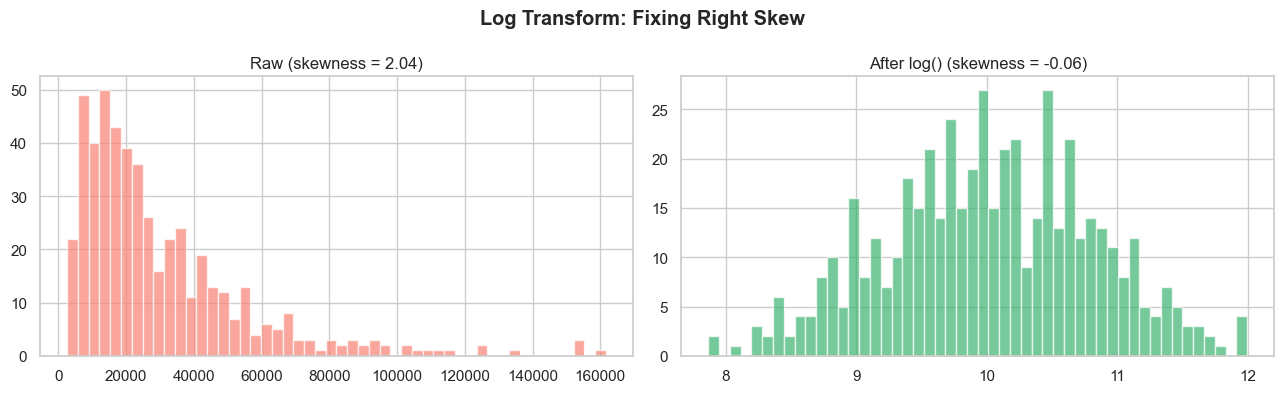

In [14]:
raw = np.random.lognormal(mean=10, sigma=0.8, size=500)
log_transformed = np.log(raw)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(raw, bins=50, color='salmon', alpha=0.7, edgecolor='white')
axes[0].set_title(f'Raw (skewness = {stats.skew(raw):.2f})')

axes[1].hist(log_transformed, bins=50, color='mediumseagreen', alpha=0.7, edgecolor='white')
axes[1].set_title(f'After log() (skewness = {stats.skew(log_transformed):.2f})')

plt.suptitle('Log Transform: Fixing Right Skew', fontweight='bold')
plt.tight_layout()
plt.show()

Left-skewed (negative skew) data is actually less common than right-skewed, which is why examples are harder to think of.

**Real-world left-skewed examples:**

- **Exam scores** — most students score high, a few fail badly. Scores cluster near the top with a tail going left
- **Age at retirement** — most people retire around 60-65, a few retire very early (35-40)

For left-skewed data, common fixes are:

| **Transform** | **How** | **When** |
|---|---|---|
| Square / Power | x² or x³ | Mild left skew |
| Reflect + Log | log(max(x) + 1 - x) | The standard fix — flip it, then log |
| Square root (reflected) | sqrt(max(x) + 1 - x) | Lighter version |

The reflect trick is the key idea — since left skew is just right skew flipped, you mirror the data first, apply log, done.

## Practice

**1.** You have a column of product prices. The mean is $450 but the median is $180.
- What does this tell you about the distribution?
- What transformation would you apply before feeding it to a linear model?  

=> It means that the data is right skewed. The skewness(outliers to the right) is pulling the mean towards the right end.  
For solving the skewness problem, I will apply the log transform to normalize the data and fix the skewness.  

**2.** Run `stats.shapiro()` on `np.random.exponential(scale=2, size=100)`.
- What result do you expect before running it?
- Does the QQ plot confirm?  

=> After running the above code, I got statistic value of around 0.725(1 would mean perfectly normal). also the p value is around 2.246e-12 which ver less tahn 0.05. Another thing is that since we are using the test on exponential data it is by default right skewed. So obviously, it is not normal distribution.

**3.** You have user session durations (in seconds). Most are under 60s but a few are 3600s+.
- Which is more meaningful to report: mean or median? Why?
- Would you remove those extreme values or transform them?  

=> Here in this case the large values denote the outliers. It will make the data right skewed. So in this case, we should use median which are robust to outliers.  
For the extreme values we have to first find out if they are real data points(genuine outliers) or error(or bug). If they are not valid data points then we remove them otherwise we keep them and log transform.  
Transforming blindly without asking "should this data even be here?" is a common mistake. Always investigate outliers before deciding what to do with them.



## Key Takeaways

- **Mean vs Median gap** → skew is present, don't use mean blindly
- **IQR fences** → standard outlier detection, used before modeling
- **Know your distribution** → it determines what tests and transforms apply
- **QQ plot** → quick visual check: are these normal enough for my test?
- **Log transform** → go-to fix for right-skewed positive data

In [15]:
stats.shapiro(np.random.exponential(scale=2, size=100))

ShapiroResult(statistic=np.float64(0.7257823541207067), pvalue=np.float64(2.246324633344969e-12))